# DeepAR with RNNs and Transformers for Time Series Forecasting


### Generative Deep Learning Coruse

**Pablo Martínez Olmos, Vanessa Gómez Verdejo, Emilio Parrado Hernández**

Department of Signal Theory and Communications


<img src='http://www.tsc.uc3m.es/~emipar/BBVA/INTRO/img/logo_uc3m_foot.jpg' width=400 />


In this example, we will develop a simple probabilistic model for time series, in which an RNN will predict the expected evolution of a time series. Given a set of signals $\mathcal{D}=\{X^1,X^2,\ldots,X^N\}$ where $$X^i = [X_0^i,X_1^i,\ldots,X_T^i]$$
is the $i$-th signal, we will fit a probabilistic model of the form
$$p(X|X_0) = \prod_{t=1}^T p(X_t|\mathbf{X}_{0:t-1})$$
where $\mathbf{X}_{0:t-1}=[X_0,X_1,\ldots,X_{t-1}]$ and each conditional factor $p(X_t|\mathbf{X}_{0:t-1})$ corresponds to a Gaussian distribution with constant variance $\sigma^2$ (which we consider a hyperparameter) and a mean given by the **output of an RNN** with input $X_{t-1}$. The RNN state $\mathbf{h}_{t-1}$ therefore contains the information of the signal up to time $t-2$, that is, $\mathbf{X}_{0:t-2}$:

$$p(X_t|X_{t-1},\mathbf{X}_{0:t-2}) = \mathcal{N}\left(f_{RNN}(X_{t-1},\mathbf{h}_{t-1}),\sigma^2+g_{RNN}(X_{t-1})\right)$$

**Important:** during training, we feed the RNN with the **true** values of the signal, that is, at each time step
$\mathbf{h}_{t-1}$ is computed using the real values of the signal. This technique is known as **teacher forcing**.


In [16]:
import torch
from torch import nn
from torch import optim
import numpy as np
import time
import matplotlib.pyplot as plt

%matplotlib inline
%config InlineBackend.figure_format = 'retina'  #To get figures with high quality!


## Part I. Creation of a Synthetic Set of Signals

We generate $N$ signals of length $T$ as a realization of the autoregressive model
\begin{align}
X_{t}=c+\sum_{i=1}^{p} \varphi_{i} X_{t-i}+\varepsilon_{t}
\end{align}
where $\varepsilon_{t}\sim \mathcal{N}(0,\sigma_{\epsilon})$ and $c$, $\varphi_{i}$ for $i=1,\ldots,p$ are real coefficients.


In [17]:
#!pip install statsmodels

In [18]:
# Generamso las señales usando la librería statsmodels

import statsmodels.api as sm

maparams = []
arparams = np.array([.35, .35,0.75,-0.65,-0.15,0.01]) #coeficients 

ar = np.r_[1, -arparams]
ma = np.r_[1, maparams]
model = sm.tsa.ArmaProcess(ar, ma) # c=0 and variance equal to 1


In [19]:
N = 1000

T = 300

T_train = 100

X = model.generate_sample((N,T),axis=1,burnin=50) 

filter_size = 3

X = np.apply_along_axis(lambda x: np.convolve(x, np.ones(filter_size)/filter_size, mode='valid'), axis=1, arr=X)

T = X.shape[1]


In [20]:
X.shape

(1000, 298)

Given the set of signals, we will create the *targets* simply as the original signals shifted:

In [21]:
Y = X[:,1:]
X = X[:,:-1]

T -=1

In [22]:
X.shape

(1000, 297)

Let's plot one of these signals against the *target*, which is nothing more than the same signal shifted to the right:


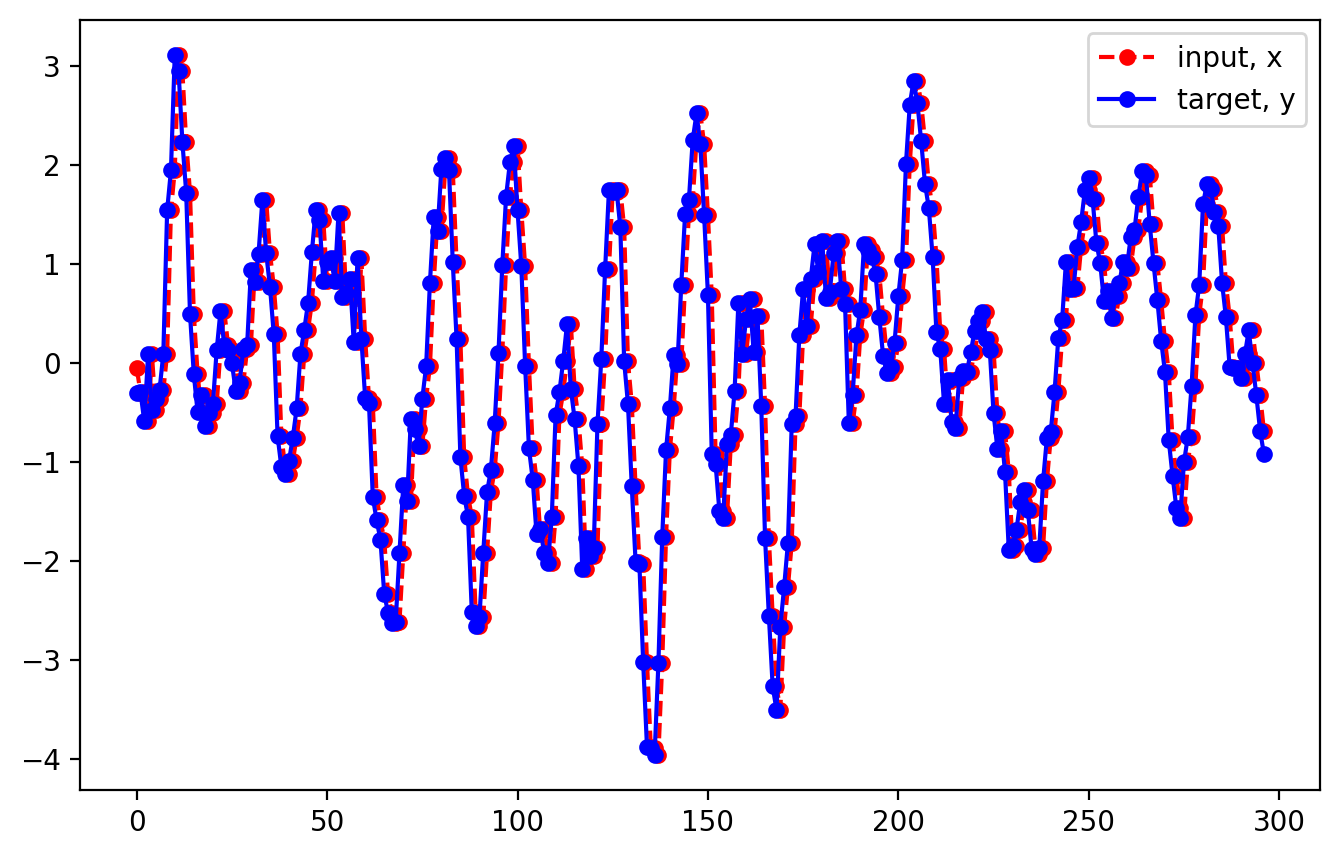

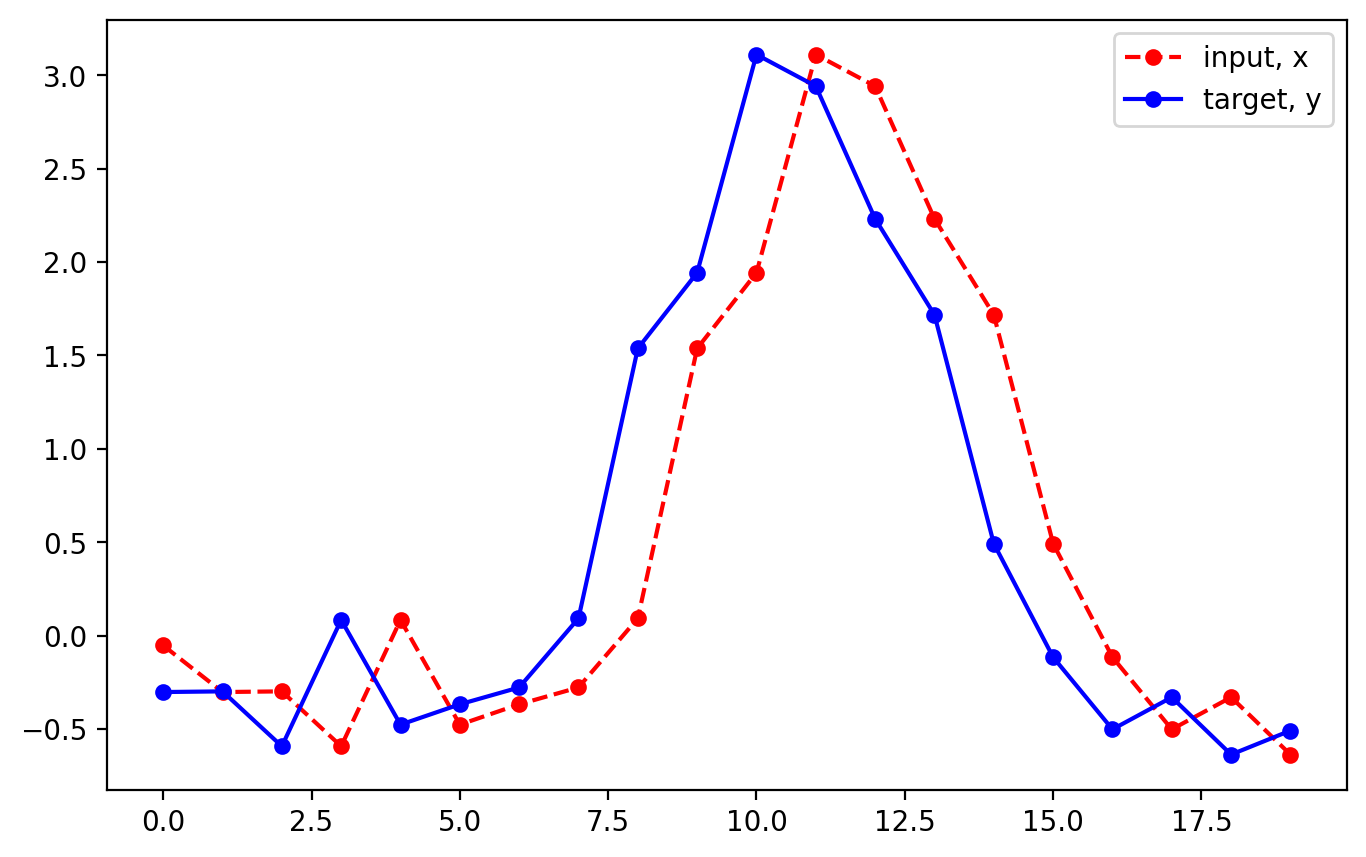

In [23]:
# Plot the signal
plt.figure(figsize=(8,5))
plt.plot(np.arange(T), X[1,:T], 'r.--', label='input, x',ms=10) # x
plt.plot(np.arange(T), Y[1,:T], 'b.-', label='target, y',ms=10) # y

plt.legend(loc='best')

# Plot the signal (20 first steps)
plt.figure(figsize=(8,5))
plt.plot(np.arange(20), X[1,:20], 'r.--', label='input, x',ms=10) # x
plt.plot(np.arange(20), Y[1,:20], 'b.-', label='target, y',ms=10) # y

plt.legend(loc='best')

## Part II. Building the RNN

Next, we build the RNN in PyTorch. We will start with a basic RNN, using `nn.RNN` whose relevant parameters are:
* **input_size** – dimension of $X_t$ (1 for us, since we are dealing with one-dimensional signals)
* **hidden_dim** – dimension of the RNN state
* **n_layers** – Number of RNN layers, typically 1–3; a value greater than one means we will create a **hierarchical RNN** (**stacked RNN**)

Here is an example of a hierarchical RNN:

<img src="https://miro.medium.com/v2/resize:fit:1400/format:webp/0*sBfgsRRLyknLfca7.jpg" width="40%">

As described in the [documentation](https://pytorch.org/docs/stable/nn.html#rnn), `nn.RNN` only provides the evolution of the states over time (what we do with them is handled externally):
\begin{align}
\mathbf{h}_{t-1} = \tanh\left(\mathbf{W}_{x}X_{t-1}+\mathbf{W}_{h}\mathbf{h}_{t-2}+\mathbf{b}_h\right)
\end{align}

Given the sequence of states, we will use a dense MLP layer to estimate the mean of $p(X_t|X_{t-1},\mathbf{X}_{0:t-2})$ given $\mathbf{h}_{t-1}$. **This layer will be linear; we do not use any output activation**.

Finally, special care must be taken with the input/output tensor dimensions of the RNN, as shown in the [documentation](https://pytorch.org/docs/stable/nn.html#rnn). The following code will serve as an example.

The following class implements our RNN. Given the mean and variance of $p(X_t|X_{t-1},\mathbf{X}_{0:t-2})$ we train the model to maximize of the known vale of $X_t$ under such distribution (teaching forcing)


In [24]:
class RNN(nn.Module):
    def __init__(self, input_size, output_size, hidden_dim, n_layers, sigma):

        # input size -> Input signal dimension (1 in our case)
        # output size -> Output signal dimension (2 in our case, one for mean and one for variance)
        # hidden_dim -> State dimension
        # n_layers -> Number of RNN layers

        super().__init__()

        self.hidden_dim = hidden_dim

        self.input_size = input_size

        self.sigma = sigma

        self.output_size = output_size

        # RNN
        # batch_first=True means that the first dimension of our tensor indexes the data
        self.rnn = nn.RNN(input_size=input_size, hidden_size=hidden_dim, num_layers=n_layers,
                          nonlinearity='relu', batch_first=True)

        # MLP layer to estimate the signal
        self.fc0 = nn.Linear(hidden_dim, hidden_dim) # YOUR CODE HERE
        self.relu = nn.ReLU()
        self.fc1 = nn.Linear(hidden_dim, self.output_size)

        USE_GPU = True
        self.device = torch.device("cuda" if torch.cuda.is_available() and USE_GPU else "cpu")

        self.to(self.device)

    def forward(self, x, h0=None):

        batch_size = x.size(0) # Number of signals N
        seq_length = x.size(1) # T

        '''
        About the dimensions of the different tensors ...:

        - Input signal is a tensor of dimensions (batch_size, seq_length, input_size)
        - Initialization h0 of the RNN state is a tensor of dimensions (n_layers, batch_size, hidden_dim).
          If h0=None, it is internally initialized to zero.
        - The output of the RNN has dimensions (batch_size, seq_length, hidden_size).
          The output of the RNN is simply the sequence of states for each input signal

        '''

        # r_out is the sequence of states
        # hidden is simply the last state (also present in r_out); we will use it for forecasting
        r_out, hidden = self.rnn(x, h0)

        # WE MUST RESHAPE r_out to dimensions (seq_length, hidden_dim)
        r_out = r_out.reshape(-1, self.hidden_dim)

        # Estimate the mean of X_t for each time step
        aux = self.fc1(self.relu(self.fc0(r_out)))

        media = aux[:, 0]

        std = torch.nn.functional.softplus(aux[:, 1])

        std = std + (torch.ones(std.shape) * self.sigma).to(self.device)

        # Noise with variance sigma
        noise = torch.randn_like(media) * std

        # Sample from X_t|X_{t-1}, h_{t-1}
        sample = media + noise

        # Reshape
        sample = sample.reshape([-1, seq_length, int(self.output_size / 2)])
        media = media.reshape([-1, seq_length, int(self.output_size / 2)])
        std = std.reshape([-1, seq_length, int(self.output_size / 2)])

        return media, std, hidden, sample


> **Exercise:** Instantiate the RNN class using `hidden_dim=32`, `n_layers=1` and `sigma=1`

In [25]:
my_rnn = RNN(input_size=1, output_size=2, hidden_dim=32, n_layers=1,sigma=1)

> **Exercise:** Using the `forward` method, compare the predicted signal against the true value during the first 20 time steps for one of the signals. Keep in mind that the RNN parameters have not been trained...

La dimensión del estado es
torch.Size([1, 1000, 32])

La dimensión de predicción es
torch.Size([1000, 297, 1])


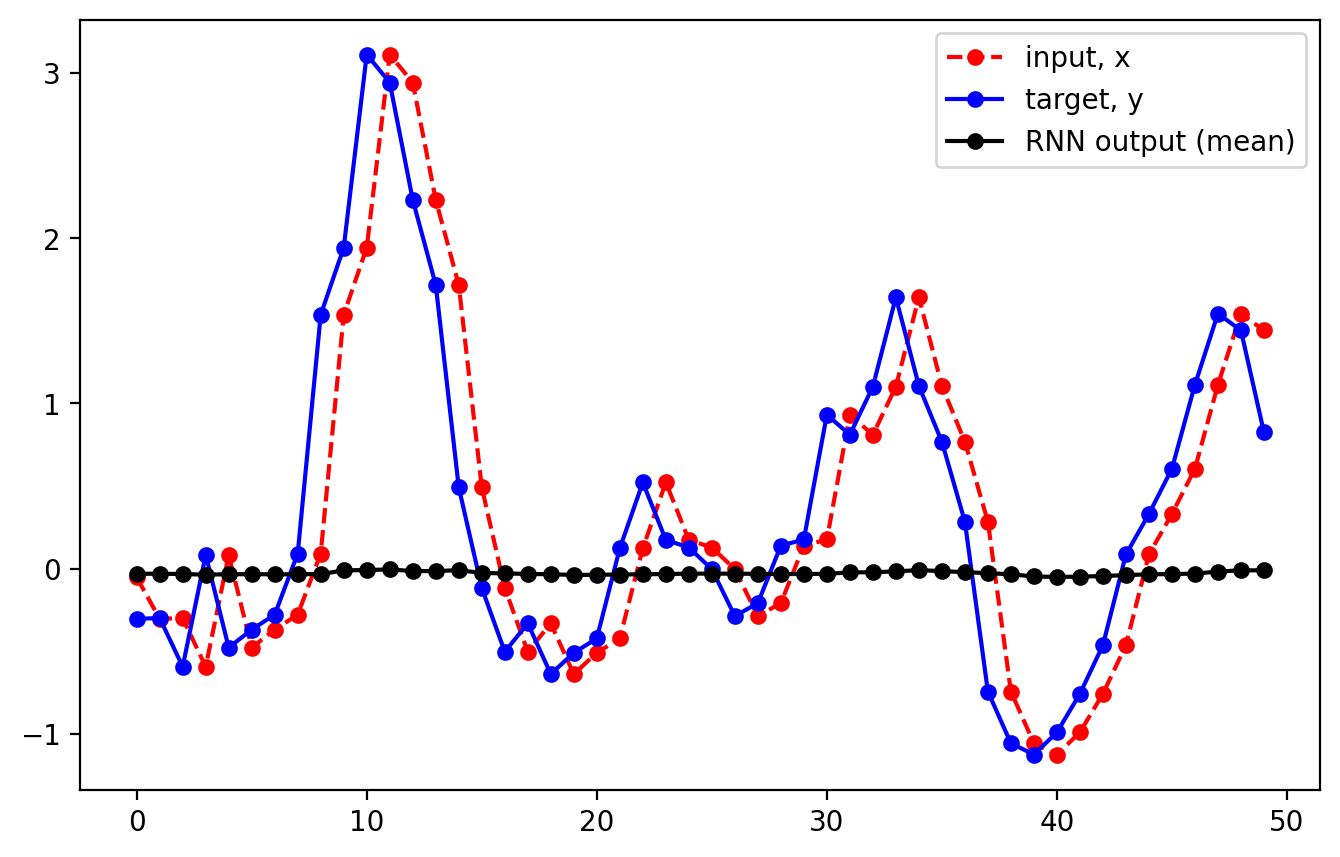

In [26]:
X_in = torch.Tensor(X).view([-1,T,1]) 

my_rnn.device = 'cpu'
my_rnn.to(my_rnn.device)

mean,std,h,sample = my_rnn.forward(X_in) 

print(f'La dimensión del estado es')
print(h.shape)

print(f'\nLa dimensión de predicción es')
print(mean.shape)

output_no_train = mean.detach().numpy().reshape([N,-1])

# Initial time
t0 = 0

# Final time
tf = 50

signal = 1 # Signal example

# Plot the first training signal and the target
plt.figure(figsize=(8,5))
plt.plot(np.arange(t0,tf,1), X[signal,t0:tf], 'r.--', label='input, x',ms=10)
plt.plot(np.arange(t0,tf,1), Y[signal,t0:tf], 'b.-', label='target, y',ms=10)
plt.plot(np.arange(t0,tf,1), output_no_train[signal,t0:tf], 'k.-', label='RNN output (mean)',ms=10)
plt.legend()



With the following code, we add the part corresponding to training. Note that in this case we are not working with mini-batches of data—on each iteration, we compute gradients using all 1000 signals. The only novelty, typically associated with RNNs, is limiting the absolute value of the gradients (*gradient clipping*) to a predefined value (2.0 in the code). When processing very long sequences, the product of terms involved in *backpropagation* can lead to excessively large gradients ([*exploding gradients*](https://www.cs.toronto.edu/~rgrosse/courses/csc321_2017/readings/L15%20Exploding%20and%20Vanishing%20Gradients.pdf)) that cause instability in gradient descent. With *gradient clipping*, we prevent this situation.


In [27]:
class RNN_extended(RNN):


    def __init__(self, num_data_train, num_iter, sequence_length,
                 input_size, output_size, hidden_dim, n_layers, sigma, lr=0.001):

        super().__init__(input_size, output_size, hidden_dim, n_layers,sigma)

        self.hidden_dim = hidden_dim

        self.sequence_length = sequence_length

        self.output_size = output_size

        self.num_layers = n_layers

        self.lr = lr

        self.num_train = num_data_train

        self.optim = optim.Adam(self.parameters(), self.lr)

        self.num_iter = num_iter


        self.loss_during_training = []

        torch.autograd.set_detect_anomaly(True)

    def gaussian_nll(self, y, mean, std):
        # Avoid log(0) or division by zero
        eps = 1e-6
        std = std + eps

        var = std ** 2
        log_prob = -0.5 * (torch.log(2 * torch.pi * var) + ((y - mean) ** 2) / var)
        return -log_prob.mean()  # Negative log-likelihood (average over all elements)



    def trainloop(self,x,y):

        # SGD Loop

        for e in range(int(self.num_iter)):

            self.optim.zero_grad()

            x = torch.Tensor(x).view([self.num_train,self.sequence_length,int(self.output_size/2)]).to(self.device)

            y = torch.Tensor(y).view([self.num_train,self.sequence_length,int(self.output_size/2)]).to(self.device)

            mean,std,hid,out = self.forward(x)

            loss = self.gaussian_nll(y, mean, std)

            loss.backward()

            #Gradient clipping!
            nn.utils.clip_grad_norm_(self.parameters(), 2.0)

            self.optim.step()

            self.loss_during_training.append(loss.item()/self.num_iter)

            if(e % 50 == 0): # Every 10 iterations

                print("Iteration %d. Training loss: %f" %(e,self.loss_during_training[-1]))

> **Exercise:** Instantiate the `RNN_extended` class with `hidden_dim=32`, `n_layers=1` and `sigma=1`.
>
> Using **only the first 100 time steps of each signal**, train the RNN 

In [28]:
my_rnn = RNN_extended(num_data_train=X.shape[0],num_iter=150,sequence_length=T_train,
                     input_size=1,output_size=2,hidden_dim=32,n_layers=1,sigma=0.5,lr=0.005)

In [29]:
my_rnn.trainloop(X[:,:T_train],Y[:,:T_train])

Iteration 0. Training loss: 0.012712
Iteration 50. Training loss: 0.004073
Iteration 100. Training loss: 0.003901


Let's plot the cost function over time...


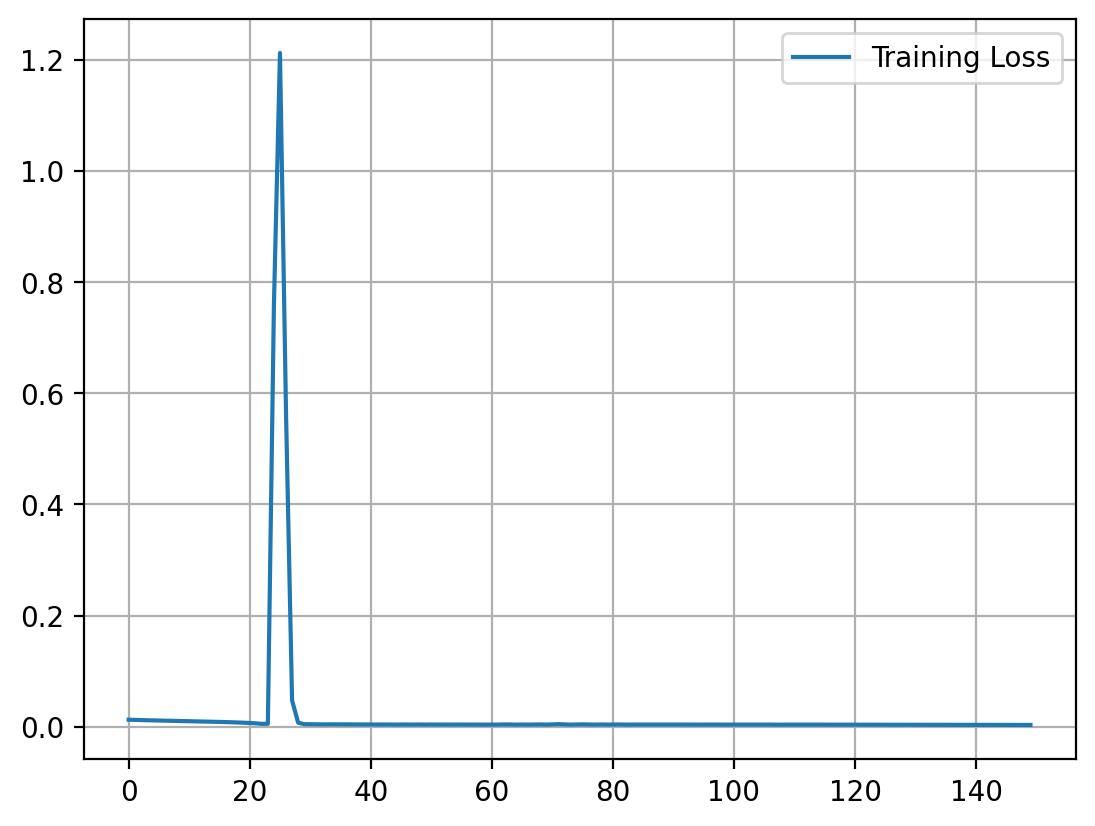

In [30]:
plt.plot(my_rnn.loss_during_training,label='Training Loss')
plt.grid()
plt.legend()

> **Exercise:** Plot the prediction against the target signal.

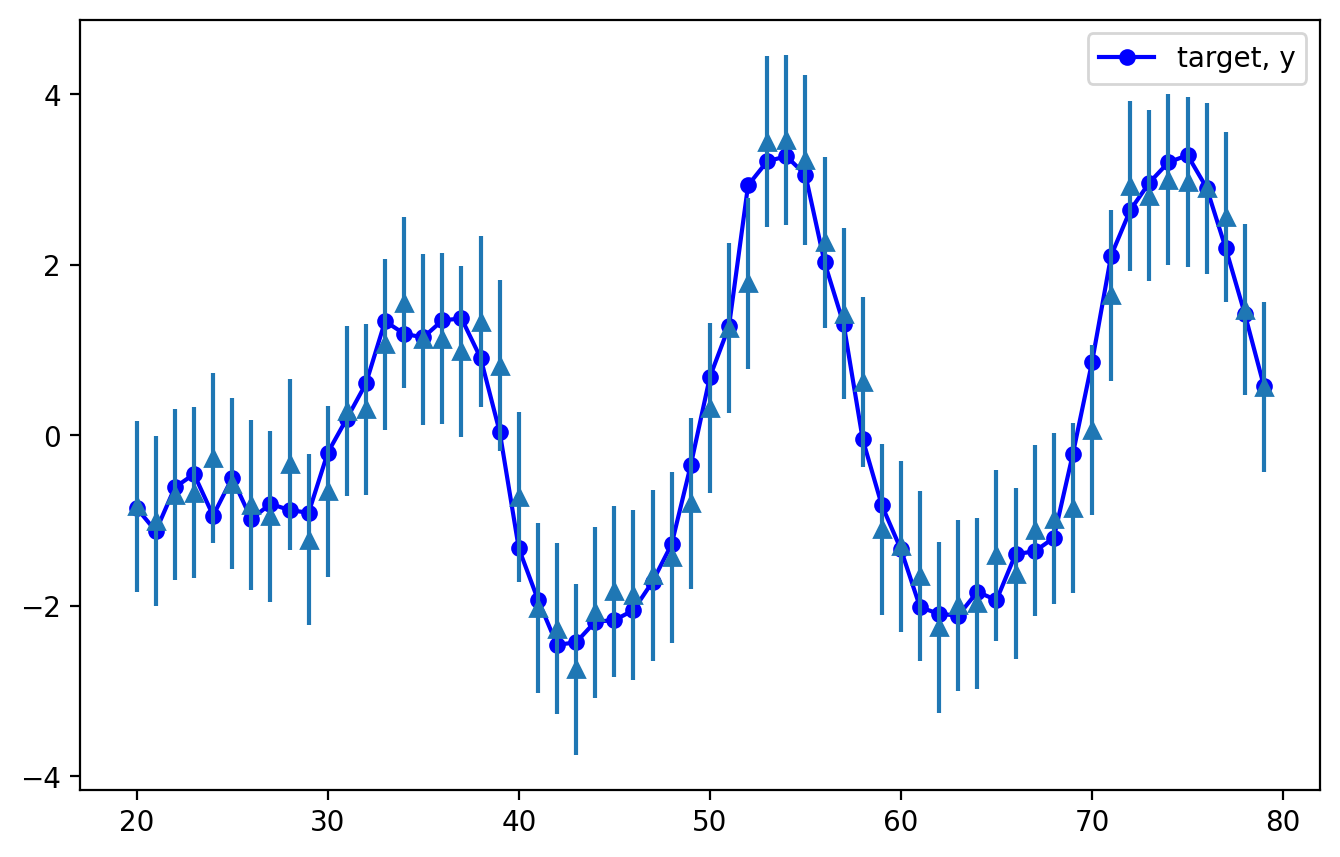

In [31]:
my_rnn.device = 'cpu'
my_rnn.to(my_rnn.device)

# We first evaluate the model for the N signals up to time T_train = 100
X_in = torch.Tensor(X[:,:T_train]).view([N,T_train,1])

mean,std,h,sample = my_rnn.forward(X_in)

mean_rnn = mean.detach().numpy().reshape([N,-1])
std_rnn = std.detach().numpy().reshape([N,-1])

# Initial time
t0 = 20

# Instante final
tf = 80

signal = 10 # From 1 to N (you can play with this)

# Plot the first training signal and the target
plt.figure(figsize=(8,5))
plt.plot(np.arange(t0,tf,1), Y[signal,t0:tf], 'b.-', label='target, y',ms=10) # x

plt.errorbar(np.arange(t0,tf,1), mean_rnn[signal,t0:tf], 2*std_rnn[signal,t0:tf], linestyle='None', marker='^')




plt.legend(loc='best')

### Sampling the Signal Evolution (*signal forecasting*)

Using the same model, we can sample the complete signal over a specified time period. That is, we will feed the RNN with the output and the state obtained at the previous time step. This is equivalent to sampling from our probabilistic model.

The following code implements the sampling of the signals from the last training time step, `T_train=100`, to `T=200`.


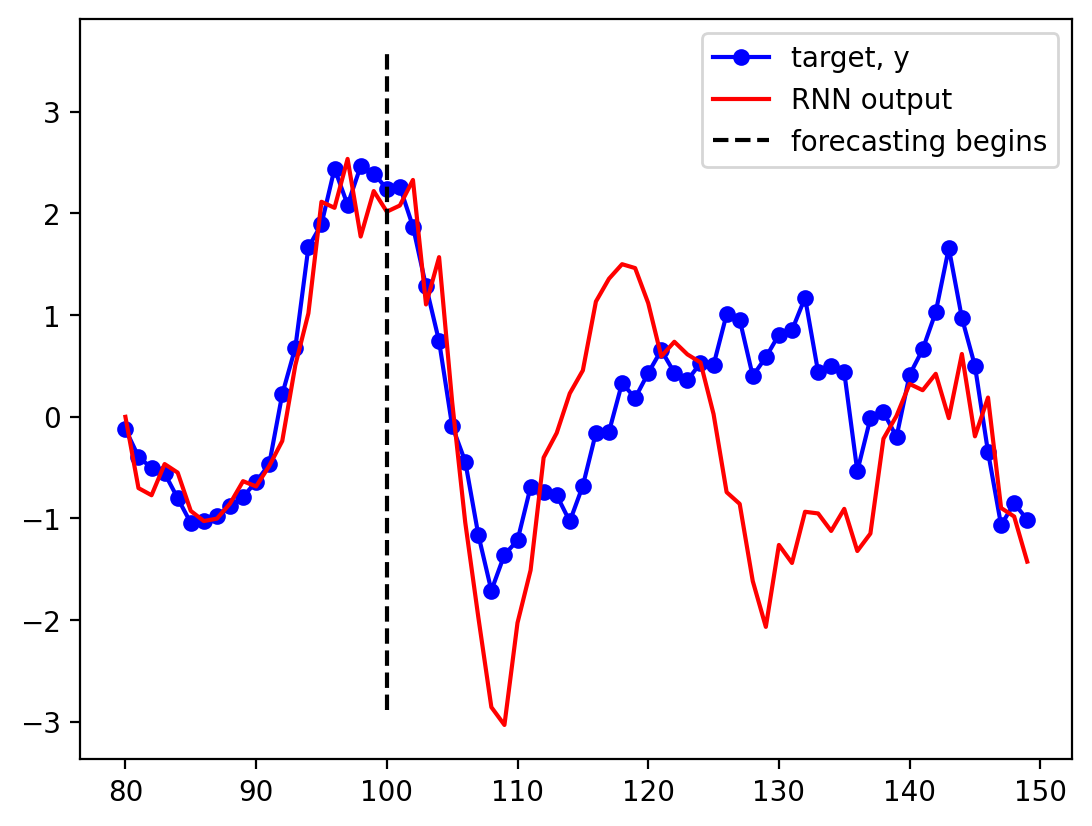

In [32]:
# We take the last output of the RNN for the N signals at time T_train
current_input = sample[:,-1,:].view([N,1,1])
# And the last state
current_state = h

# Sampled signals
forecast_rnn = np.zeros([N,T-T_train])

for t in range(T-T_train):

    # In this loop we iteratively sample the model

    mean,std,current_state,current_input = my_rnn.forward(current_input,current_state)

    forecast_rnn[:,t] = current_input.detach().numpy().reshape([-1,])


# We concatenate the original signals (up to T_train) with the sampled ones (from T_train onward)
final_rnn_reconstruct = np.hstack([mean_rnn,forecast_rnn])

# We plot the original and reconstructed signals

t0 = 80

tfinal = 150

plt.plot(np.arange(t0,tfinal,1), Y[signal,t0:tfinal].reshape([-1]), 'b.-', label='target, y',ms=10)
plt.plot(np.arange(t0,tfinal,1), final_rnn_reconstruct[signal,t0:tfinal], 'r-', label='RNN output',ms=10)
plt.plot([T_train,T_train],[np.min(Y[signal,:]),np.max(Y[signal,:])],'k--',label='forecasting begins')
plt.legend()

plt.legend(loc='best')


## Part III. LSTMs

Let's now see if an LSTM improves prediction in this problem. We can create an LSTM with `nn.LSTM`; it is recommended to read the [documentation](https://pytorch.org/docs/stable/generated/torch.nn.LSTM.html#torch.nn.LSTM). The syntax of the class is very similar to the previous one. The only difference is that if we use `n_layers>1` with the option `dropout=prob`, we can automatically include a dropout layer between each of the stacked LSTM layers, where `prob` is the associated dropout probability.

```python
self.lstm = nn.LSTM(input_size, n_hidden, n_layers,
                            dropout=drop_prob, batch_first=True)
```
> **Exercise:** Complete the code for the following two classes



In [33]:
class LSTM(nn.Module):
    def __init__(self, input_size, output_size, hidden_dim, n_layers, sigma, drop_prob):

        # input size -> Input signal dimension (1 in our case)
        # output size -> Output signal dimension (1 in our case)
        # hidden_dim -> State dimension
        # n_layers -> Number of RNN layers

        super().__init__()

        self.hidden_dim = hidden_dim

        self.input_size = input_size
        self.output_size = output_size

        self.sigma = sigma

        self.lstm = nn.LSTM(input_size, hidden_dim, n_layers, dropout=drop_prob, batch_first=True) # YOUR CODE HERE

        # MLP layer to estimate the signal
        self.fc0 = nn.Linear(hidden_dim, hidden_dim) # YOUR CODE HERE
        self.relu = nn.ReLU()
        self.fc1 = nn.Linear(hidden_dim, self.output_size)

        USE_GPU = True
        self.device = torch.device("cuda" if torch.cuda.is_available() and USE_GPU else "cpu")

        self.to(self.device)

    def forward(self, x, h0=None, valid=False):

        batch_size = x.size(0) # Number of signals N
        seq_length = x.size(1) # T

        '''
        About the dimensions of the different tensors ...:

        - Input signal is a tensor of dimensions (batch_size, seq_length, input_size)
        - Initialization h0 of the RNN state is a tensor of dimensions (n_layers, batch_size, hidden_dim).
          If h0=None, it is internally initialized to zero.
        - The output of the LSTM has dimensions (batch_size, seq_length, hidden_size).
          The output of the LSTM is simply the sequence of states for each input signal

        '''

        if(valid):
            self.eval() # To enable/disable dropout if using n_layers>1
        else:
            self.train()

        # r_out is the sequence of states
        # hidden is simply the last state (also present in r_out); we will use it for forecasting
        r_out, hidden = self.lstm(x, h0)

        # WE MUST RESHAPE r_out to dimensions (seq_length, hidden_dim)
        r_out = r_out.reshape(-1, self.hidden_dim)

        # Estimate the mean of X_t for each time step
        aux = self.fc1(self.relu(self.fc0(r_out)))

        media = aux[:, 0]

        std = torch.nn.functional.softplus(aux[:, 1])

        std = std + (torch.ones(std.shape) * self.sigma).to(self.device)

        # Noise with variance sigma
        noise = torch.randn_like(media) * std

        # Sample from X_t|X_{t-1}, h_{t-1}
        sample = media + noise

        # Reshape
        sample = sample.reshape([-1, seq_length, int(self.output_size / 2)])
        media = media.reshape([-1, seq_length, int(self.output_size / 2)])
        std = std.reshape([-1, seq_length, int(self.output_size / 2)])

        return media, std, hidden, sample


In [34]:
class LSTM_extended(LSTM):

    # Your code here

    def __init__(self, num_data_train, num_iter, sequence_length,
                 input_size, output_size, hidden_dim, n_layers, sigma, drop_prob=0.3, lr=0.001):

        super().__init__(input_size, output_size, hidden_dim, n_layers, sigma, drop_prob)

        self.hidden_dim = hidden_dim

        self.output_size = output_size

        self.sequence_length = sequence_length

        self.num_layers = n_layers

        self.lr = lr  # Learning Rate

        self.num_train = num_data_train  # Number of training signals

        self.optim = optim.Adam(self.parameters(), self.lr)

        self.num_iter = num_iter

        self.loss_during_training = []

    def gaussian_nll(self, y, mean, std):
        # Avoid log(0) or division by zero
        eps = 1e-6
        std = std + eps

        var = std ** 2
        log_prob = -0.5 * (torch.log(2 * torch.pi * var) + ((y - mean) ** 2) / var)
        return -log_prob.mean()  # Negative log-likelihood (average over all elements)

    def trainloop(self, x, y):

        # SGD Loop

        for e in range(int(self.num_iter)):

            self.optim.zero_grad()

            x = torch.Tensor(x).view([self.num_train, self.sequence_length, int(self.output_size / 2)]).to(self.device)

            y = torch.Tensor(y).view([self.num_train, self.sequence_length, int(self.output_size / 2)]).to(self.device)

            mean, std, hid, out = self.forward(x)  # YOUR CODE HERE

            loss = self.gaussian_nll(y, mean, std)

            loss.backward()

            # Gradient clipping!
            nn.utils.clip_grad_norm_(self.parameters(), 2.0)

            self.optim.step()

            self.loss_during_training.append(loss.item() / self.num_iter)

            if(e % 50 == 0):  # Every 50 iterations

                print("Iteration %d. Training loss: %f" % (e, self.loss_during_training[-1]))


> **Exercise:** Using `hidden_dim=32`, `n_layers=1` and `sigma=1`, train the LSTM for 150 iterations using the first 100 time steps of each signal. Since `n_layers=1`, the dropout parameter has no effect (PyTorch will give us a warning).


In [35]:
my_lstm = LSTM_extended(num_data_train=X.shape[0],num_iter=150,sequence_length=T_train,
                     input_size=1,output_size=2,hidden_dim=32,n_layers=1,sigma=0.5,lr=0.005)

/export/gts_usuarios/olmos/miniconda3/envs/scbm/lib/python3.11/site-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(


In [36]:
my_lstm.trainloop(X[:,:T_train],Y[:,:T_train]) #YOUR CODE HERE

Iteration 0. Training loss: 0.012308
Iteration 50. Training loss: 0.004106
Iteration 100. Training loss: 0.003884


Let's plot the evolution of the cost function...

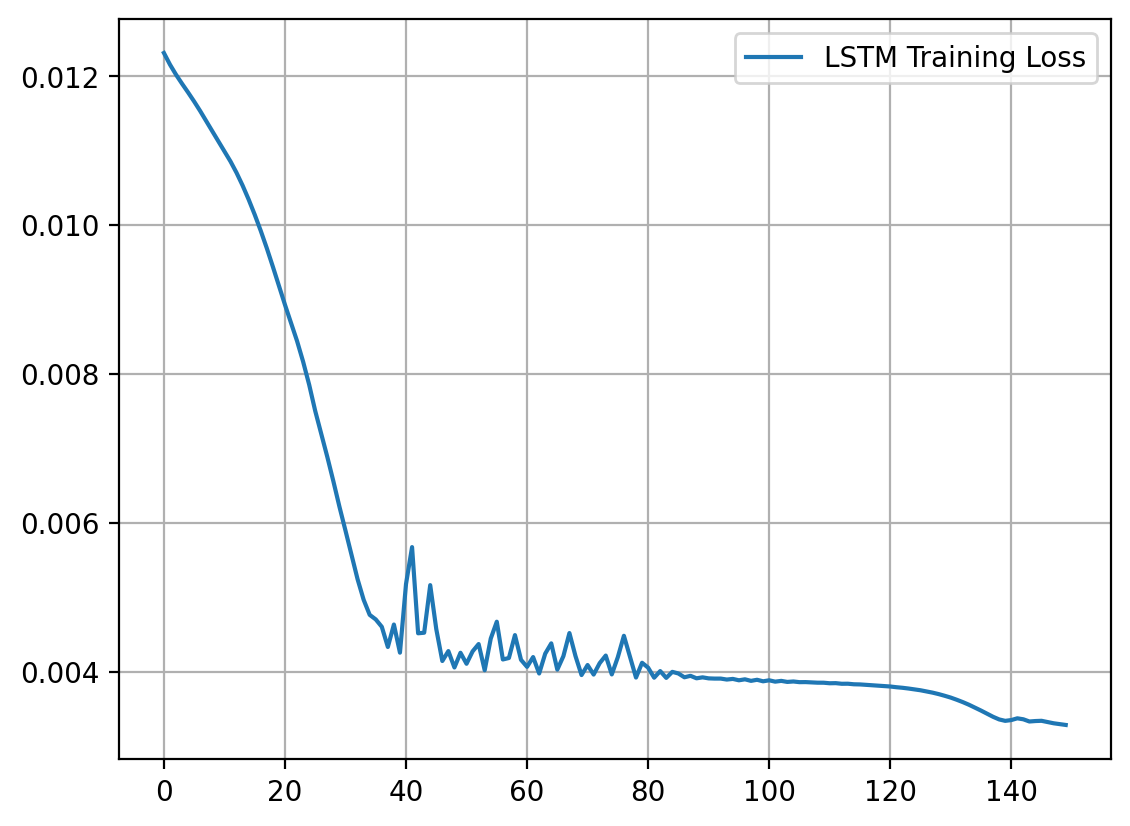

In [37]:
plt.plot(my_lstm.loss_during_training,label='LSTM Training Loss')
plt.grid()
plt.legend()


In terms of next-step prediction with *teacher forcing*, both models achieve similar performance. Keep in mind that the memory of the autoregressive model we used to generate the signals is limited...

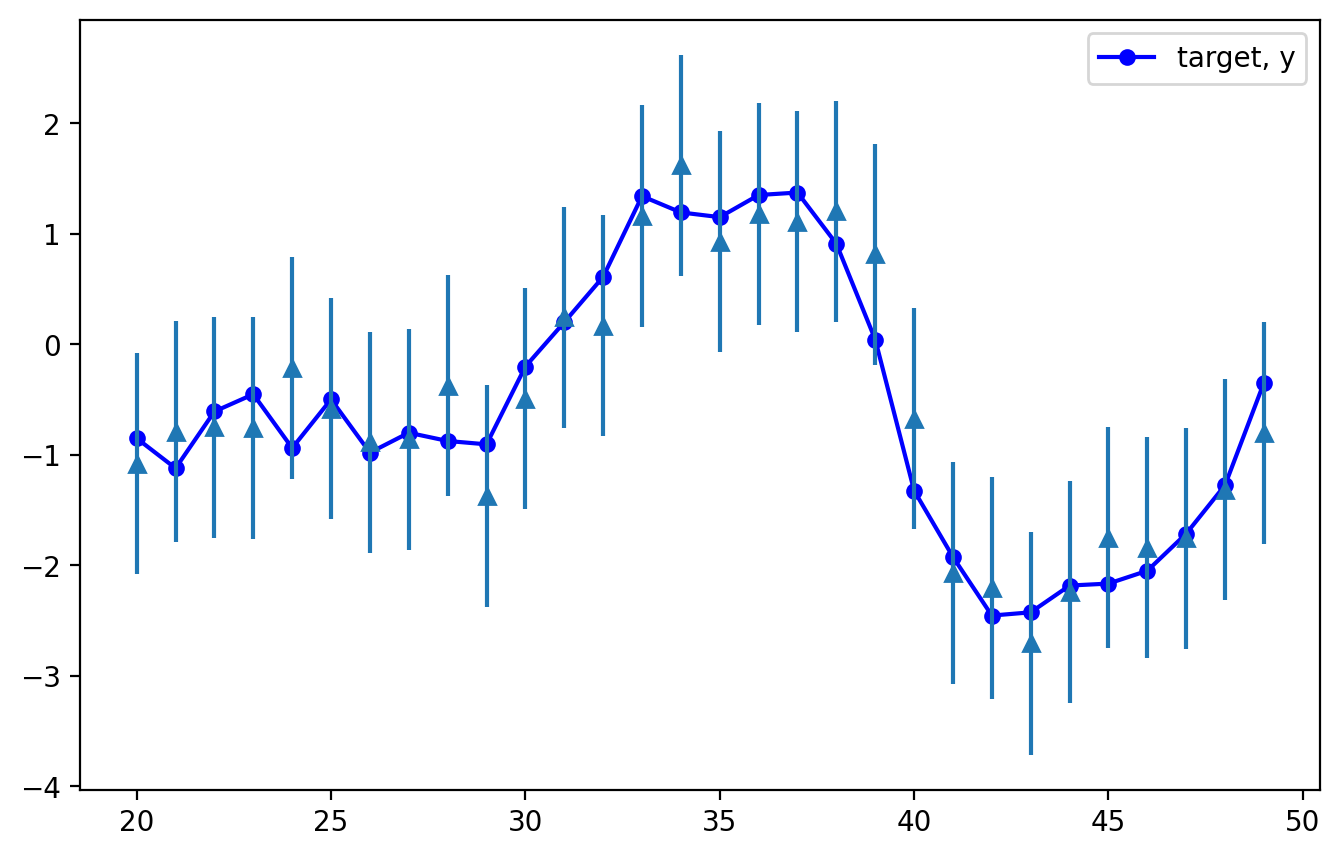

In [38]:
# We first evaluate the model for the N signals up to time T_train = 100
X_in = torch.Tensor(X[:,:T_train]).view([N,T_train,1]) # YOUR CODE HERE

my_lstm.device = 'cpu'
my_lstm.to(my_lstm.device)  

mean, std, h, sample = my_lstm.forward(X_in) # YOUR CODE HERE

mean_lstm = mean.detach().numpy().reshape([N,-1])
std_lstm = std.detach().numpy().reshape([N,-1])

# Initial time step for the plot
t0 = 20

# Final time step
tf = 50

signal = 10 # From 1 to N (you can play with this)

# Plot the first training signal and the target
plt.figure(figsize=(8,5))
plt.plot(np.arange(t0,tf,1), Y[signal,t0:tf], 'b.-', label='target, y',ms=10) # x

plt.errorbar(np.arange(t0,tf,1), mean_lstm[signal,t0:tf], 2*std_lstm[signal,t0:tf], linestyle='None', marker='^')

plt.legend(loc='best')


### Sampling the Model with LSTMs

Let's repeat the sampling experiment, this time using the LSTM

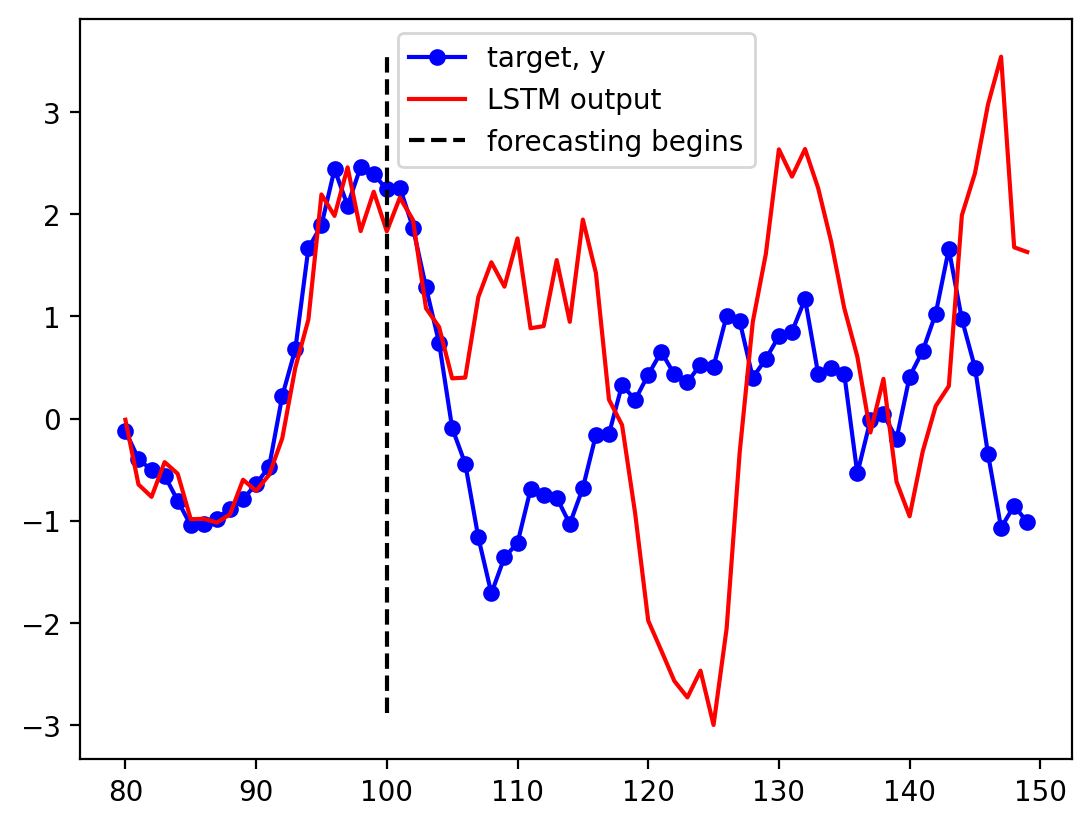

In [39]:
# We take the last output of the RNN for the N signals at time T_train
current_input = sample[:,-1,:].view([N,1,1])
# And the last state
current_state = h

# Sampled signals
forecast_lstm = np.zeros([N,T-T_train])

for t in range(T-T_train):

    # In this loop, we iteratively sample the model

    mean, std, current_state, current_input = my_lstm.forward(current_input, current_state)

    forecast_lstm[:,t] = current_input.detach().numpy().reshape([-1,])


# We concatenate the original signals (up to T_train) with the sampled ones (from T_train onward)
final_lstm_reconstruct = np.hstack([mean_lstm, forecast_lstm])

# We plot the original and reconstructed signals

t0 = 80

tfinal = 150

plt.plot(np.arange(t0, tfinal, 1), Y[signal, t0:tfinal].reshape([-1]), 'b.-', label='target, y', ms=10)
plt.plot(np.arange(t0, tfinal, 1), final_lstm_reconstruct[signal, t0:tfinal], 'r-', label='LSTM output', ms=10)
plt.plot([T_train, T_train], [np.min(Y[signal, :]), np.max(Y[signal, :])], 'k--', label='forecasting begins')
plt.legend()

plt.legend(loc='best')


### 1D-CNN + Transformer

De forma similar, hacemos uso de un transformer, alimentado por la salida de una 1D-CNN y con el correspondiente *positional encoding*

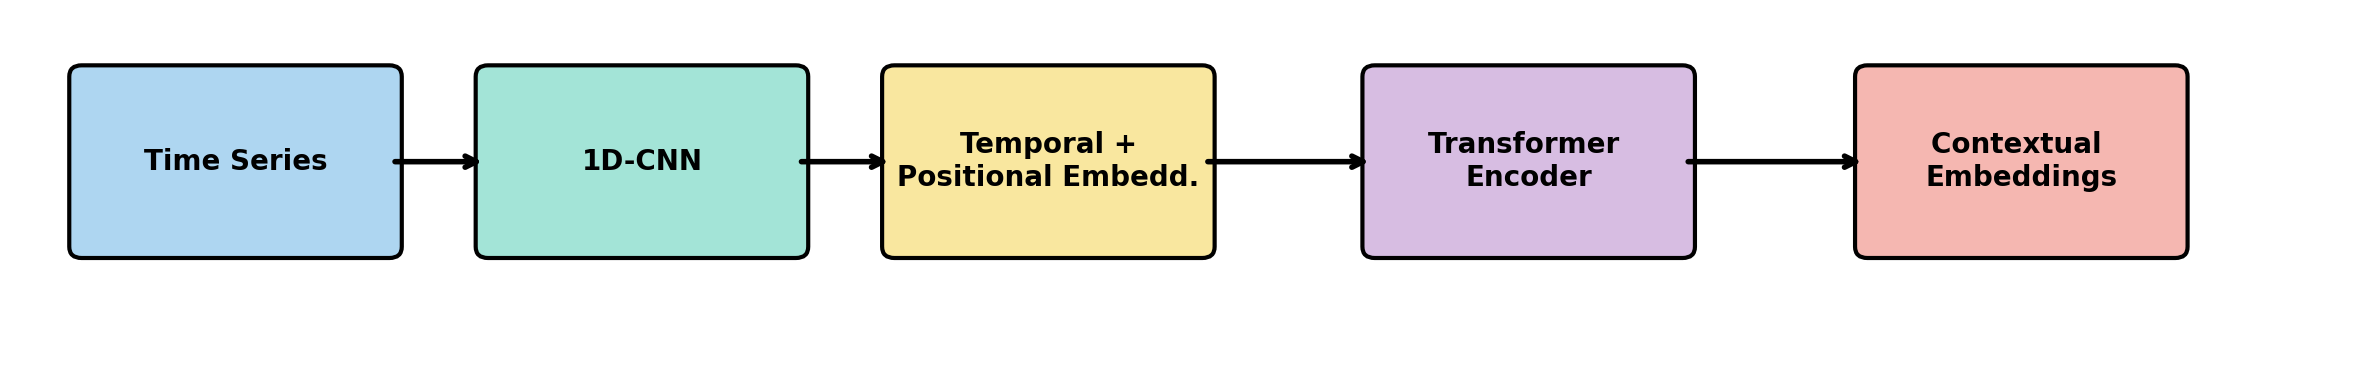

In [40]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(12, 2))

# Define blocks with labels and colors
blocks = [
    ("Time Series", "#AED6F1"),
    ("1D-CNN", "#A3E4D7"),
    ("Temporal +\nPositional Embedd.", "#F9E79F"),
    ("Transformer \nEncoder", "#D7BDE2"),
    ("Contextual \nEmbeddings", "#F5B7B1")
]

positions = [-0.5, 2.8, 6.1, 10, 14]

# Draw colored rectangles with centered text
for (label, color), x in zip(blocks, positions):
    rect = patches.FancyBboxPatch((x, 0), 2.5, 1.5, boxstyle="round,pad=0.1", linewidth=1.5,
                                   edgecolor='black', facecolor=color)
    ax.add_patch(rect)
    ax.text(x + 1.25, 0.75, label, ha='center', va='center', fontsize=10, weight='bold')

# Draw arrows between blocks
for i in range(len(positions) - 1):
    ax.annotate('', xy=(positions[i+1], 0.75), xytext=(positions[i]+2.5, 0.75),
                arrowprops=dict(arrowstyle='->', lw=2, color='black'))

# Final plot settings
ax.set_xlim(-1, 18)
ax.set_ylim(-1, 2)
ax.axis('off')
plt.tight_layout()
plt.show()



In [41]:
import math

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(-math.log(10000.0) * torch.arange(0, d_model, 2).float() / d_model)
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # shape (1, max_len, d_model)
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


class LSTMTransformer(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, lstm_layers=1,
                 d_model=16, nhead=4, num_layers=2, dim_feedforward=128,
                 dropout=0.1, output_size=2, max_seq_len=150, sigma = 1.):
        super(LSTMTransformer, self).__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size,
                            num_layers=lstm_layers, batch_first=True)

        self.embedding_proj = nn.Linear(hidden_size, d_model)
        self.pos_encoder = PositionalEncoding(d_model, max_len=max_seq_len)
        self.output_size = output_size
        self.hidden_dim = d_model
        self.sigma = 1.

        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model,
                                                   nhead=nhead,
                                                   dim_feedforward=dim_feedforward,
                                                   dropout=dropout,
                                                   batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        # Dense layer to estimate the signal
        self.fc0 = nn.Linear(d_model, d_model) 
        self.relu = nn.ReLU()
        self.fc1 = nn.Linear(d_model, self.output_size)

        USE_GPU = True
        self.device = torch.device( "cuda" if torch.cuda.is_available()and USE_GPU else "cpu")

        self.to(self.device)

    def forward(self, x):
        """
        x: shape (batch_size, seq_len, 1)
        """
        seq_length = x.size(1) # T
        lstm_out, _ = self.lstm(x.to(self.device))  # shape: (batch_size, seq_len, hidden_size)
        x = self.embedding_proj(lstm_out)  # project to d_model
        x = self.pos_encoder(x)  # add positional encoding
        r_out = self.transformer_encoder(x)  # apply transformer layers
        # Reshape r_out to dimensions (seq_length, hidden_dim)
        r_out = r_out.reshape(-1, self.hidden_dim)

        
        aux = self.fc1(self.relu(self.fc0(r_out)))

        # mean
        media = aux[:,0]

        # std
        std = torch.nn.functional.softplus(aux[:,1])

        std = std+(torch.ones(std.shape)*self.sigma).to(self.device) #Término cte de la std

        # Sampling noise
        noise = torch.randn_like(media)*std

        # Sample X_t|X_{t-1},h_{t-1}
        sample = media + noise

        # Reshaping
        sample = sample.reshape([-1,seq_length,int(self.output_size/2)])
        media = media.reshape([-1,seq_length,int(self.output_size/2)])
        std = std.reshape([-1,seq_length,int(self.output_size/2)])


        return media, std, r_out, sample



In [42]:
my_transformer = LSTMTransformer(d_model=16,nhead=2, num_layers=3, dim_feedforward=64,
                                 input_size=1, hidden_size=16, lstm_layers=1,
                                 output_size=2, max_seq_len=T_train, sigma=0.5)

Output dimension
torch.Size([100000, 16])


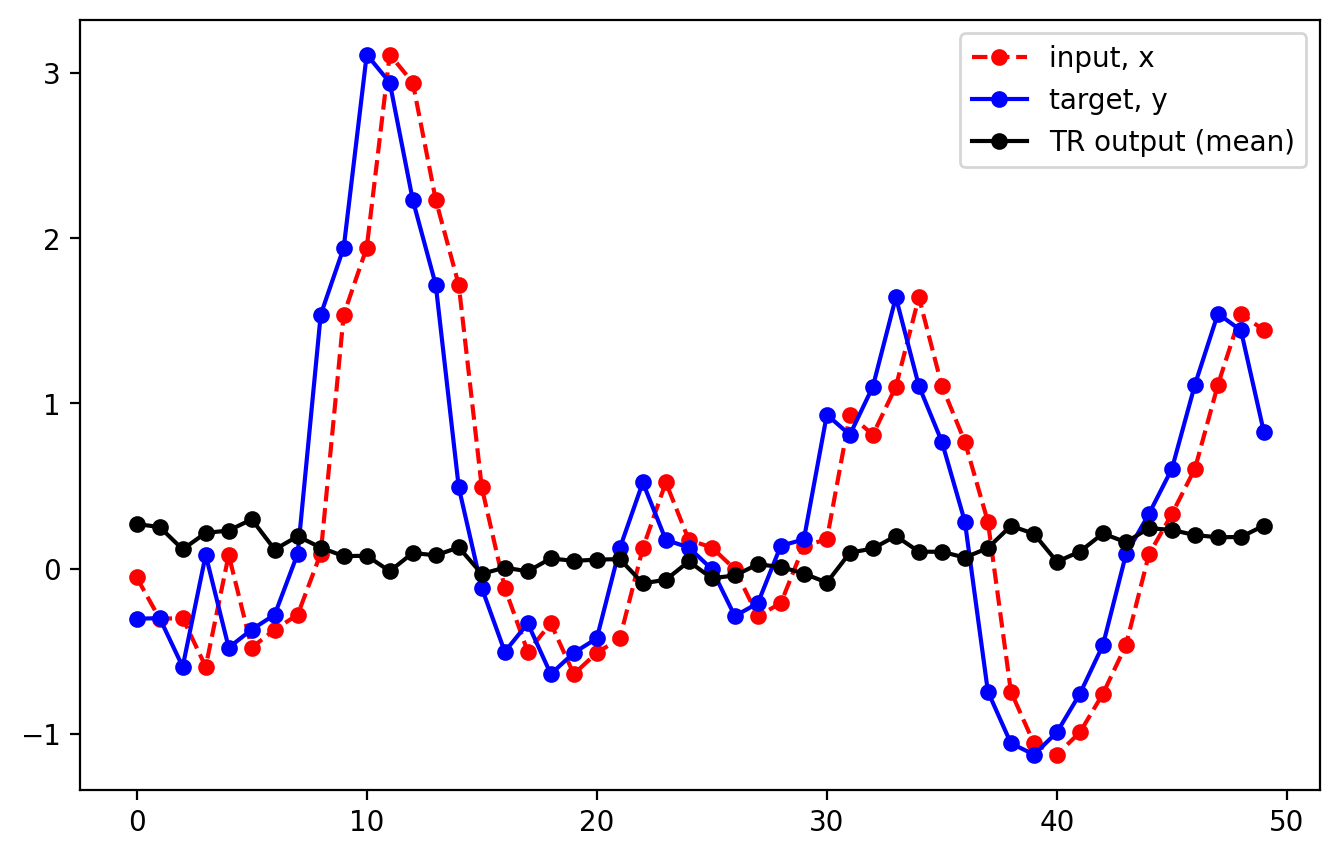

In [43]:
X_in = torch.Tensor(X[:,:100]).view([-1,100,1]).to(my_transformer.device)

mean,std,h,sample = my_transformer.forward(X_in) # YOUR CODE HERE

print(f'Output dimension')
print(h.shape)


output_no_train = mean.cpu().detach().numpy().reshape([N,-1])

t0 = 0

tf = 50

signal = 1

# Plot the first training signal and the target
plt.figure(figsize=(8,5))
plt.plot(np.arange(t0,tf,1), X[signal,t0:tf], 'r.--', label='input, x',ms=10)
plt.plot(np.arange(t0,tf,1), Y[signal,t0:tf], 'b.-', label='target, y',ms=10)
plt.plot(np.arange(t0,tf,1), output_no_train[signal,t0:tf], 'k.-', label='TR output (mean)',ms=10)
plt.legend()

In [44]:
class TR_extended(LSTMTransformer):

    #Your code here

    def __init__(self, num_data_train = 50, num_iter = 200, sequence_length = 50, input_size=1, hidden_size=32, lstm_layers=1,
                 d_model=16, nhead=4, num_layers=3, dim_feedforward=32,
                 dropout=0.1, output_size=2, max_seq_len=150, sigma = 1., drop_prob=0.3, lr=0.005):


        super().__init__(input_size, hidden_size, lstm_layers,
                 d_model, nhead, num_layers, dim_feedforward,
                 dropout, output_size, max_seq_len, sigma = 1.)

        self.hidden_dim = d_model

        self.output_size = output_size

        self.sequence_length = sequence_length

        self.lr = lr #Learning Rate

        self.num_train = num_data_train #Number of training signals

        self.optim = optim.Adam(self.parameters(), self.lr)

        self.num_iter = num_iter

        self.loss_during_training = []


    def gaussian_nll(self, y, mean, std):
        # Avoid log(0) or division by zero
        eps = 1e-6
        std = std + eps

        var = std ** 2
        log_prob = -0.5 * (torch.log(2 * torch.pi * var) + ((y - mean) ** 2) / var)
        return -log_prob.mean()  # Negative log-likelihood (average over all elements)


    def trainloop(self,x,y):

        # SGD Loop

        for e in range(int(self.num_iter)):

            self.optim.zero_grad()

            x = torch.Tensor(x).view([self.num_train,self.sequence_length,int(self.output_size/2)]).to(self.device)

            y = torch.Tensor(y).view([self.num_train,self.sequence_length,int(self.output_size/2)]).to(self.device)

            mean,std,hid,out = self.forward(x) #YOUR CODE HERE

            loss = self.gaussian_nll(y, mean, std)

            loss.backward()

            #Gradient clipping!
            nn.utils.clip_grad_norm_(self.parameters(), 2.0)

            self.optim.step()

            self.loss_during_training.append(loss.item()/self.num_iter)

            if(e % 50 == 0): # Every 10 iterations

                print("Iteration %d. Training loss: %f" %(e,self.loss_during_training[-1]))

In [45]:
my_TF= TR_extended(d_model=16, num_layers=4, nhead = 4, dim_feedforward=16, hidden_size=16, num_data_train=X.shape[0],num_iter=500,sequence_length=T_train,lr=0.01,sigma=0.1)

In [46]:
my_TF.trainloop(X[:,:T_train],Y[:,:T_train])

Iteration 0. Training loss: 0.003650
Iteration 50. Training loss: 0.002043
Iteration 100. Training loss: 0.002013
Iteration 150. Training loss: 0.001987
Iteration 200. Training loss: 0.001958
Iteration 250. Training loss: 0.001943
Iteration 300. Training loss: 0.001930
Iteration 350. Training loss: 0.001922
Iteration 400. Training loss: 0.001912
Iteration 450. Training loss: 0.001900


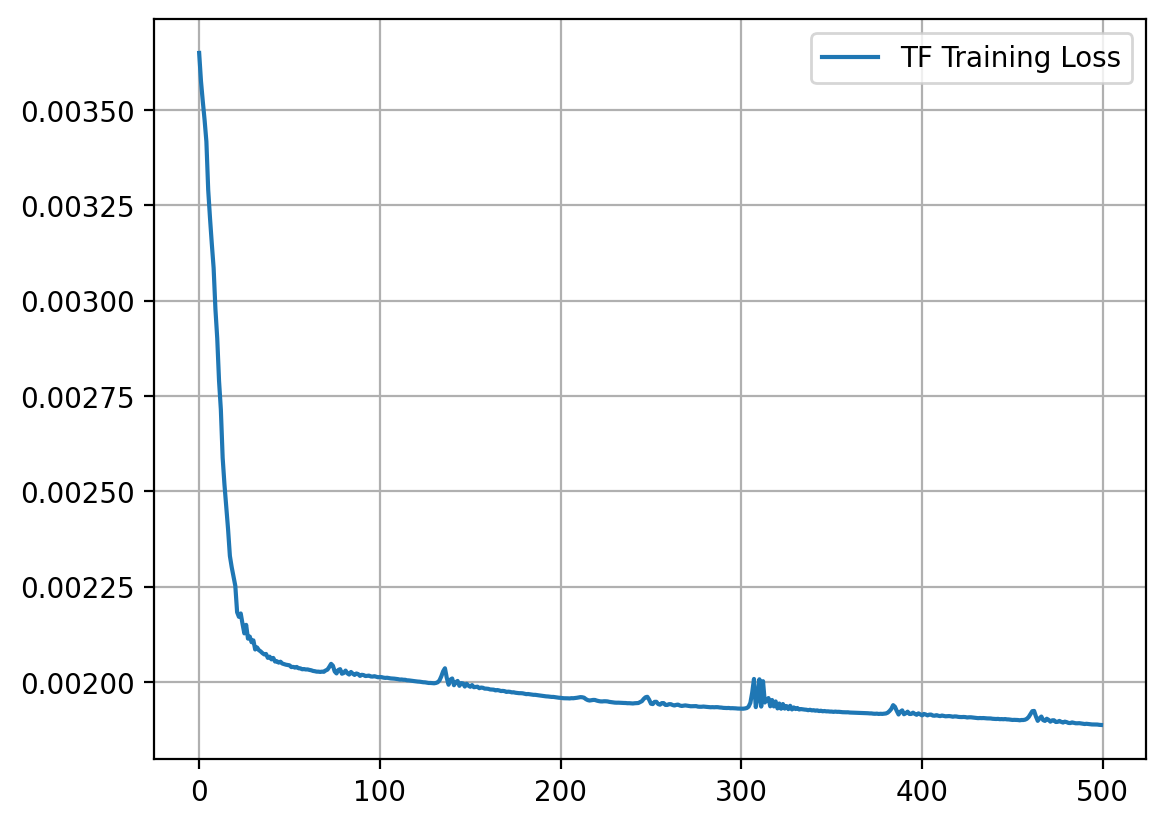

In [47]:
plt.plot(my_TF.loss_during_training,label='TF Training Loss')
plt.grid()
plt.legend()


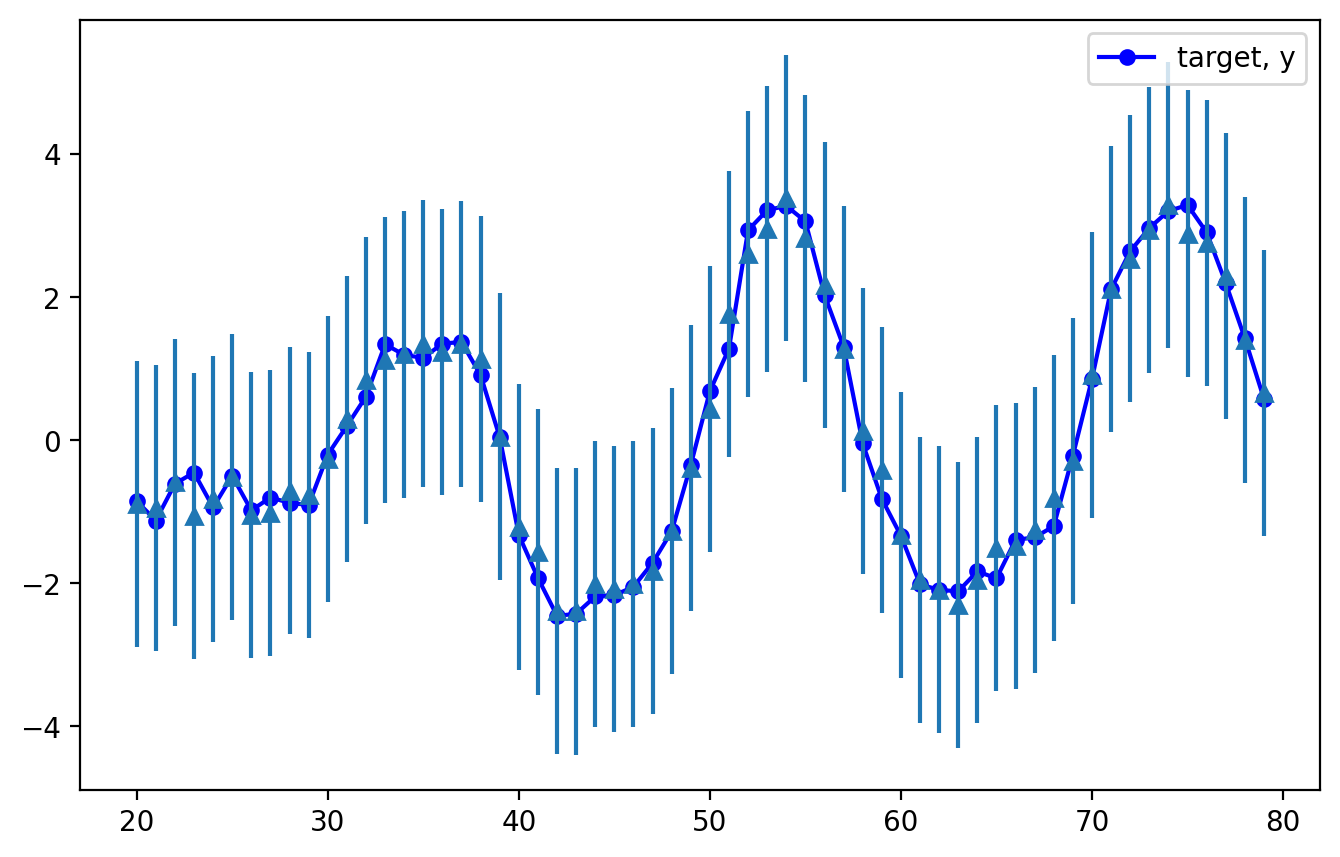

In [48]:
my_TF.device = "cpu"
my_TF.to(my_TF.device)

# We first evaluate the model for the N signals up to time T_train = 100
X_in = torch.Tensor(X[:,:T_train]).view([N,T_train,1]).cpu() # YOUR CODE HERE

mean,std,h,sample = my_TF.forward(X_in) # YOUR CODE HERE

mean_TF = mean.cpu().detach().numpy().reshape([N,-1])
std_TF = std.cpu().detach().numpy().reshape([N,-1])

t0 = 20

tf = 80

signal = 10 # From 1 to N (you can play with this)

# Plot the first training signal and the target
plt.figure(figsize=(8,5))
plt.plot(np.arange(t0,tf,1), Y[signal,t0:tf], 'b.-', label='target, y',ms=10) # x

plt.errorbar(np.arange(t0,tf,1), mean_TF[signal,t0:tf], 2*std_TF[signal,t0:tf], linestyle='None', marker='^')




plt.legend(loc='best')

In [ ]:
current_signal = X_in.clone()  # Clone to avoid modifying original input

T_forecasting = 50
# Sampled signals
forecast_TF = np.zeros([N, T_forecasting])

for t in range(T_forecasting):

    # In this loop we iteratively sample the model
    mean, std, current_state, output = my_TF.forward(current_signal)

    # Store the output in forecast array (assumes 1D output per signal)
    forecast_TF[:, t] = output[:, -1, 0].detach().cpu().numpy()

    # Update current_signal: remove first time step, add new output
    new_input = output[:, -1, :].unsqueeze(1)  # shape (N, 1, 1)
    current_signal = torch.cat([current_signal[:, 1:, :], new_input], dim=1)

# Concatenate the original signals (up to T_train) with the sampled ones (from T_train onward)
final_TF_reconstruct = np.hstack([mean_TF, forecast_TF])

# Plot the original and reconstructed signals
t0 = 80
tfinal = T_train + T_forecasting

plt.plot(np.arange(t0, tfinal, 1), Y[signal, t0:tfinal].reshape([-1]), 'b.-', label='target, y', ms=10)
plt.plot(np.arange(t0, tfinal, 1), final_TF_reconstruct[signal, t0:tfinal], 'r-', label='TF output')
plt.plot([T_train, T_train], [np.min(Y[signal, :]), np.max(Y[signal, :])], 'k--', label='forecasting begins')
plt.legend(loc='best')
plt.show()

